In [1]:
%matplotlib inline
import pickle
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

import os as _os, sys as _sys
_HERE = _os.getcwd()
_ROOT = _HERE if _os.path.isdir(_os.path.join(_HERE, "mcpilco")) else _os.path.dirname(_HERE)
_os.chdir(_ROOT)
_sys.path.insert(0, _ROOT)
_sys.path.insert(0, _os.path.dirname(_ROOT))

from mcpilco.config_single_phase import get_config
from mcpilco.pensim_wrapper import (PenSimWrapper, PenSimMCPILCO, STATE_NAMES,
                                     STATE_RANGES, WARMUP_H, T_SAMPLING, PAA_BAND)

PAA_IDX = STATE_NAMES.index("PAA")
P_IDX = STATE_NAMES.index("P")

In [2]:
seed = 1
trial = None
num_trials = 10
fast = False
results_dir = "results/single_phase/cluster/"

In [3]:
def _denorm(x, lo, hi):
    return lo + (x + 1.0) * (hi - lo) / 2.0


def _denorm_delta(d, lo, hi):
    return d * (hi - lo) / 2.0


def _resolve_trial(log, trial):
    avail = sorted(int(k.split("_")[-1]) for k in log if k.startswith("parameters_gp_"))
    if not avail:
        raise RuntimeError("log.pkl has no parameters_gp_<i> (no trained GP to load)")
    if trial is None:
        return avail[-1]
    if trial not in avail:
        raise RuntimeError(f"trial {trial} not in saved GP trials {avail}")
    return trial


def reconstruct(seed, num_trials, fast, log, idx):
    cfg = get_config(seed=seed, num_trials=num_trials, fast=fast)
    cfg["mc_pilco_init"]["log_path"] = None
    agent = PenSimMCPILCO(pensim_wrapper=PenSimWrapper(**cfg["wrapper_par"]),
                          **cfg["mc_pilco_init"])
    agent.state_samples_history = log["state_samples_history"]
    agent.input_samples_history = log["input_samples_history"]
    agent.noiseless_states_history = log.get("noiseless_states_history",
                                             log["state_samples_history"])

    ml = agent.model_learning
    ml.gp_inputs = log[f"gp_inputs_{idx}"]
    ml.gp_output_list = log[f"gp_output_list_{idx}"]
    ml.num_samples = ml.gp_inputs.shape[0]
    ml.dim_state = len(STATE_NAMES)
    ml.init_gp_models()
    params = log[f"parameters_gp_{idx}"]
    for k in range(ml.num_gp):
        ml.gp_list[k].load_state_dict(params[k])
        ml.norm_list[k] = torch.max(torch.abs(ml.gp_output_list[k]))
    with torch.no_grad():
        for k in range(ml.num_gp):
            ml.pretrain_gp(k)
    ml.set_eval_mode()
    return agent

In [4]:
d = Path(results_dir) / f"seed{seed}"
log = pickle.load(open(d / "log.pkl", "rb"))
idx = _resolve_trial(log, trial)

agent = reconstruct(seed, num_trials, fast, log, idx)

with torch.no_grad():
    _, targets, means, _ = agent.get_model_learning_performance(idx)
    pred, true, _ = agent.get_rollout_prediction_performance(idx)



Get the system...


Get the learning object...
GP APPROXIMATION SELECTED
APPROXIMATION MODE:  SOD
APPROXIMATION OPTIONS:  {'SOD_threshold_mode': 'relative', 'SOD_threshold': 0.3, 'flg_SOD_permutation': False}


Get the exploration policy...


Get the control policy...


Get the cost function...

Selection of the inducing inputs...


/Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/MSc/pensimpy_mcpilco/MC-PILCO/gpr_lib/GP_prior/GP_prior.py:106: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch release.
L = torch.cholesky(A)
should be replaced with
L = torch.linalg.cholesky(A)
and
U = torch.cholesky(A, upper=True)
should be replaced with
U = torch.linalg.cholesky(A).mH
This transform will produce equivalent results for all valid (symmetric positive definite) inputs. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:1776.)
  U = torch.cholesky(K_X, upper=True)


Shape inducing inputs selected: torch.Size([916, 10])
MSE gp 0:  tensor(0.0005, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([700, 10])
MSE gp 1:  tensor(0.0004, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([481, 10])
MSE gp 2:  tensor(9.1458e-10, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([536, 10])
MSE gp 3:  tensor(6.9094e-07, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([736, 10])
MSE gp 4:  tensor(1.7297e-05, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([751, 10])
MSE gp 5:  tensor(0.0004, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing inputs selected: torch.Size([1007, 10])
MSE gp 6:  tensor(1.3568e-05, dtype=torch.float64)

Selection of the inducing inputs...
Shape inducing in

In [5]:
per_dim_mse = [float(((targets[k] - means[k]) ** 2).mean()) for k in range(len(targets))]

lo, hi = STATE_RANGES["PAA"]
tgt_paa = _denorm_delta(targets[PAA_IDX].ravel(), lo, hi)
prd_paa = _denorm_delta(means[PAA_IDX].ravel(), lo, hi)
ss_res = float(((tgt_paa - prd_paa) ** 2).sum())
ss_tot = float(((tgt_paa - tgt_paa.mean()) ** 2).sum()) or 1.0
r2_paa = 1.0 - ss_res / ss_tot
gp_inputs = agent.model_learning.data_to_gp_input(
    torch.tensor(agent.state_samples_history[idx]),
    torch.tensor(agent.input_samples_history[idx]))[:-1, :].detach().cpu().numpy()
paa_level = _denorm(gp_inputs[:, PAA_IDX], lo, hi)

t = WARMUP_H + np.arange(pred.shape[0]) * T_SAMPLING
paa_pred = _denorm(pred[:, PAA_IDX], lo, hi);  paa_true = _denorm(true[:, PAA_IDX], lo, hi)
p_pred = _denorm(pred[:, P_IDX], *STATE_RANGES["P"])
p_true = _denorm(true[:, P_IDX], *STATE_RANGES["P"])

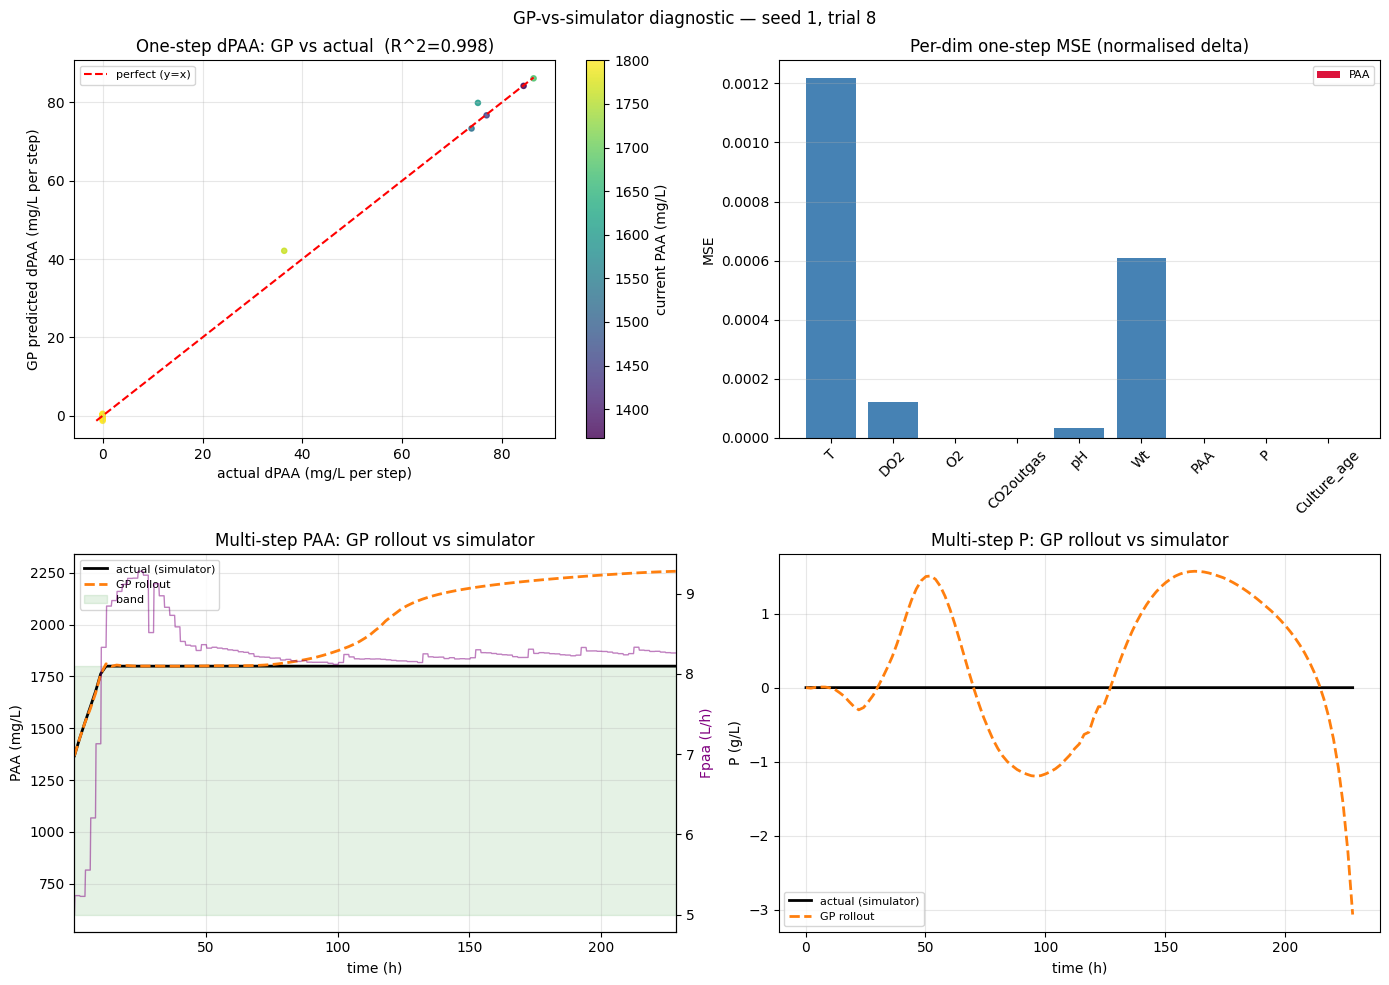

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

sc = ax[0, 0].scatter(tgt_paa, prd_paa, c=paa_level, cmap="viridis", s=14, alpha=.8)
lim = [min(tgt_paa.min(), prd_paa.min()), max(tgt_paa.max(), prd_paa.max())]
ax[0, 0].plot(lim, lim, "r--", lw=1.5, label="perfect (y=x)")
fig.colorbar(sc, ax=ax[0, 0], label="current PAA (mg/L)")
ax[0, 0].set_title(f"One-step dPAA: GP vs actual  (R^2={r2_paa:.3f})")
ax[0, 0].set_xlabel("actual dPAA (mg/L per step)")
ax[0, 0].set_ylabel("GP predicted dPAA (mg/L per step)")
ax[0, 0].grid(alpha=.3); ax[0, 0].legend(fontsize=8)

ax[0, 1].bar(range(len(per_dim_mse)), per_dim_mse, color="steelblue")
ax[0, 1].bar([PAA_IDX], [per_dim_mse[PAA_IDX]], color="crimson", label="PAA")
ax[0, 1].set_xticks(range(len(STATE_NAMES))); ax[0, 1].set_xticklabels(STATE_NAMES, rotation=45)
ax[0, 1].set_title("Per-dim one-step MSE (normalised delta)")
ax[0, 1].set_ylabel("MSE"); ax[0, 1].grid(alpha=.3, axis="y"); ax[0, 1].legend(fontsize=8)

ax[1, 0].plot(t, paa_true, "k-", lw=2, label="actual (simulator)")
ax[1, 0].plot(t, paa_pred, "C1--", lw=2, label="GP rollout")
ax[1, 0].axhspan(*PAA_BAND, color="green", alpha=.10, label="band")
ax[1, 0].set_title("Multi-step PAA: GP rollout vs simulator")
ax[1, 0].set_xlabel("time (h)"); ax[1, 0].set_ylabel("PAA (mg/L)"); ax[1, 0].grid(alpha=.3)
try:
    mon = pickle.load(open(d / "monitor.pkl", "rb"))[idx]
    axt = ax[1, 0].twinx()
    axt.plot(mon["t"], mon["Fpaa"], color="purple", lw=1, alpha=.5, label="Fpaa (action)")
    axt.set_ylabel("Fpaa (L/h)", color="purple")
    axt.set_xlim(t[0], t[-1])
except (FileNotFoundError, IndexError, KeyError):
    pass
ax[1, 0].legend(fontsize=8, loc="upper left")

ax[1, 1].plot(t, p_true, "k-", lw=2, label="actual (simulator)")
ax[1, 1].plot(t, p_pred, "C1--", lw=2, label="GP rollout")
ax[1, 1].set_title("Multi-step P: GP rollout vs simulator")
ax[1, 1].set_xlabel("time (h)"); ax[1, 1].set_ylabel("P (g/L)")
ax[1, 1].grid(alpha=.3); ax[1, 1].legend(fontsize=8)

fig.suptitle(f"GP-vs-simulator diagnostic — seed {seed}, trial {idx}")
fig.tight_layout()
plt.show()